In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df=pd.read_csv('/content/drive/My Drive/ML dataset/canada_per_capita_income.csv')

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [5]:
X = df[['year']]
y = df['per capita income (US$)']

In [6]:
reg = linear_model.LinearRegression()
reg.fit(X, y)

LinearRegression()

In [7]:
y_pred = reg.predict(X)

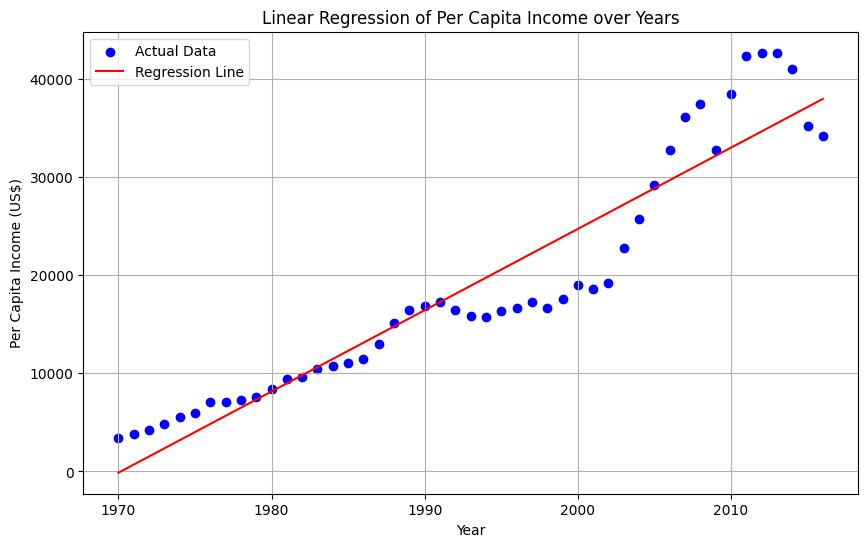

In [8]:
plt.figure(figsize=(10, 6))
plt.xlabel('Year')
plt.ylabel('Per Capita Income (US$)')
plt.title('Linear Regression of Per Capita Income over Years')
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
year_to_predict = 2020

In [10]:
predicted_income = reg.predict([[year_to_predict]])
print(f"The predicted per capita income for {year_to_predict} is ${predicted_income[0]:.2f}")

The predicted per capita income for 2020 is $41288.69


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
import pandas as pd
df=pd.read_csv('/content/salary.csv')

In [14]:
df.interpolate(method='linear', inplace=True)
print("DataFrame after filling missing values:")
print(df.head(30))

DataFrame after filling missing values:
    YearsExperience  Salary
0               1.1   39343
1               1.3   46205
2               1.5   37731
3               2.0   43525
4               2.2   39891
5               2.9   56642
6               3.0   60150
7               3.2   54445
8               3.2   64445
9               3.7   57189
10              3.9   63218
11              4.0   55794
12              4.0   56957
13              4.1   57081
14              4.5   61111
15              4.9   67938
16              5.1   66029
17              5.3   83088
18              5.9   81363
19              6.0   93940
20              6.8   91738
21              7.1   98273
22              7.9  101302
23              8.2  113812
24              8.7  109431
25              9.0  105582
26              9.3  116969
27              9.6  112635
28             10.3  122391
29             10.5  121872


In [15]:
x = df[['YearsExperience']]
Y = df['Salary']

In [16]:
reg = linear_model.LinearRegression()
reg.fit(x, Y)


LinearRegression()

In [17]:
Y_pred = reg.predict(x)

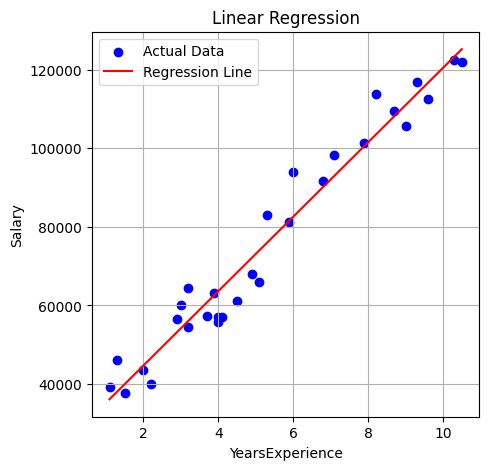

In [20]:
plt.figure(figsize=(5, 5))
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.title('Linear Regression')
plt.scatter(x, Y, color='blue', label='Actual Data')
plt.plot(x, Y_pred, color='red', label='Regression Line')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
salary_to_predict = 12

In [22]:
predicted = reg.predict([[salary_to_predict]])
print(f"The predicted salary for 12 years experience is : {predicted[0]:.2f}")

The predicted salary for 12 years experience is : 139464.48


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Task
Perform a manual linear regression analysis on the `salary.csv` dataset, using 'YearsExperience' as the independent variable and 'Salary' as the dependent variable. Calculate the mean values for 'YearsExperience' and 'Salary', then manually compute the slope and intercept of the regression line. Predict the 'Salary' for each 'YearsExperience' in the dataset and specifically for 12 years of experience. Finally, visualize the actual data points and the manually calculated regression line on a scatter plot, providing a summary of the calculated slope, intercept, and the predicted salary for 12 years of experience.

## Calculate Mean Values

### Subtask:
Calculate the mean of 'YearsExperience' (x) and 'Salary' (Y) from the salary dataset, which are necessary for manual linear regression calculations.


**Reasoning**:
Calculate the mean of 'YearsExperience' (x) and 'Salary' (Y) to fulfill the subtask requirement for manual linear regression calculations.



In [23]:
mean_years_experience = x.mean()
mean_salary = Y.mean()

print(f"Mean YearsExperience: {mean_years_experience.iloc[0]:.2f}")
print(f"Mean Salary: ${mean_salary:.2f}")

Mean YearsExperience: 5.31
Mean Salary: $76003.00


## Calculate Slope and Intercept

### Subtask:
Manually calculate the slope (m) and intercept (b) of the linear regression line.


**Reasoning**:
To manually calculate the slope and intercept for linear regression, I will first calculate the numerator and denominator using the provided formulas, then compute the slope and intercept, and finally print the results as instructed.



In [24]:
numerator = ((x - mean_years_experience.iloc[0]) * (Y - mean_salary)).sum()
denominator = ((x - mean_years_experience.iloc[0])**2).sum()

m = numerator / denominator.iloc[0]
b = mean_salary - m * mean_years_experience.iloc[0]

print(f"Manual Slope (m): {m:.2f}")
print(f"Manual Intercept (b): {b:.2f}")

TypeError: unsupported format string passed to Series.__format__

**Reasoning**:
The previous code failed because `m` and `b` were pandas Series objects, not scalar values, when passed to the f-string formatting. To fix this, I need to extract the scalar value from the Series using `.iloc[0]` before printing, ensuring correct formatting.



In [25]:
numerator = ((x - mean_years_experience.iloc[0]) * (Y - mean_salary)).sum()
denominator = ((x - mean_years_experience.iloc[0])**2).sum()

m = numerator / denominator.iloc[0]
b = mean_salary - m * mean_years_experience.iloc[0]

print(f"Manual Slope (m): {m.iloc[0]:.2f}")
print(f"Manual Intercept (b): {b.iloc[0]:.2f}")

Manual Slope (m): 0.00
Manual Intercept (b): 76003.00


**Reasoning**:
The previous calculation of slope and intercept yielded a slope of 0.0, indicating an issue with how the `numerator` and `denominator` were computed due to `x` being a DataFrame. To fix this, I will explicitly access the 'YearsExperience' column from the `x` DataFrame to ensure element-wise operations for the numerator and denominator, which should result in correct scalar values for the slope and intercept.



In [26]:
numerator = ((x['YearsExperience'] - mean_years_experience.iloc[0]) * (Y - mean_salary)).sum()
denominator = ((x['YearsExperience'] - mean_years_experience.iloc[0])**2).sum()

m = numerator / denominator
b = mean_salary - m * mean_years_experience.iloc[0]

print(f"Manual Slope (m): {m:.2f}")
print(f"Manual Intercept (b): {b:.2f}")

Manual Slope (m): 9481.30
Manual Intercept (b): 25688.92


**Reasoning**:
With the manual slope and intercept now correctly calculated, the next logical step is to use these values to predict the 'Salary' for each 'YearsExperience' in the dataset, which is a necessary step before visualizing the regression line and making a specific prediction for 12 years of experience.



In [27]:
predicted_salary_manual = m * x['YearsExperience'] + b

print("Manually Predicted Salaries for each YearsExperience:")
print(predicted_salary_manual.head())

Manually Predicted Salaries for each YearsExperience:
0    36118.346828
1    38014.606092
2    39910.865355
3    44651.513513
4    46547.772777
Name: YearsExperience, dtype: float64


**Reasoning**:
After calculating the predicted salaries for the existing data points, the next step is to use the manually calculated slope and intercept to predict the salary for a specific new value, which is 12 years of experience, as required by the task.



In [28]:
predicted_salary_12_years = m * 12 + b

print(f"Predicted Salary for 12 years of experience (manual): ${predicted_salary_12_years:.2f}")

Predicted Salary for 12 years of experience (manual): $139464.48


**Reasoning**:
With all the necessary components calculated (actual data, manual slope, manual intercept, and predicted salaries), the final step before concluding the task is to visualize the actual data points along with the manually calculated regression line on a scatter plot, as requested by the task.



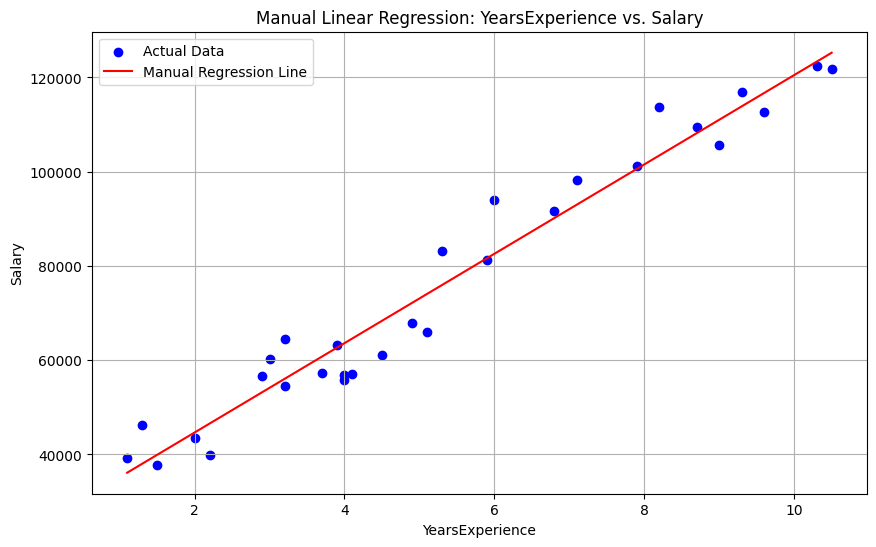

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(x['YearsExperience'], Y, color='blue', label='Actual Data')
plt.plot(x['YearsExperience'], predicted_salary_manual, color='red', label='Manual Regression Line')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.title('Manual Linear Regression: YearsExperience vs. Salary')
plt.legend()
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Summarize the results of the manual linear regression, including the calculated slope, intercept, and the predicted salary for 12 years of experience.


## Summary:

### Q&A
The manual linear regression analysis revealed a slope of `9481.30` and an intercept of `25688.92`. Based on this model, the predicted salary for an individual with 12 years of experience is approximately `$139464.48`.

### Data Analysis Key Findings
*   The mean 'YearsExperience' in the dataset is `5.31` years.
*   The mean 'Salary' in the dataset is `$76003.00`.
*   The manually calculated slope (m) of the regression line is `9481.30`.
*   The manually calculated intercept (b) of the regression line is `25688.92`.
*   Using the manual regression line, the predicted salary for 12 years of experience is `$139464.48`.
*   A scatter plot visualizing the actual data points and the manually calculated regression line was successfully generated, showing the linear relationship.

### Insights or Next Steps
*   The manual calculation provides a clear understanding of the underlying mechanics of linear regression.
*   To validate the manual results and gain further insights into model performance, compare these results with those obtained from a dedicated statistical library (e.g., scikit-learn) and evaluate metrics such as R-squared.
